# Battery trading backtest

Does the price forecast make money, how much of the possible profit does it capture,
and where is the rest lost?

**Setup.** A 1 MW / 2 MWh battery, 90% round-trip efficiency, €8 wear per MWh
discharged, starting and ending each day half full, at most two cycles a day. Every
day at 11:40 the forecast for the next day is turned into a schedule by the
optimizer (`src/trading/optimizer.py`), committed before the 12:00 gate and settled
at the realised day-ahead price. Perfect foresight runs the same optimizer on the
realised prices: it is the ceiling, and *capture ratio* is a strategy's profit
divided by the ceiling's.

**Windows.** Everything was tuned and chosen on the validation window, 1 June 2024 to
31 May 2026. The setup was then frozen and run once on the hold-out, from 1 June
2026, which no earlier phase had seen.

**Strategies.** Median and mean dispatch optimize on the median or mean of the
forecast. Quantile-aware dispatch values selling at a low quantile (q25 or q10) and
buying at the mirrored high one, so it trades only spreads that survive a pessimistic
reading of the forecast.


In [1]:
import warnings

warnings.filterwarnings("ignore")

import json
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_settings
from src.trading.attribution import HOUR_BLOCKS
from src.trading.backtest import capture_in_months, pnl_differences

settings = load_settings()
BACKTEST = settings.data.processed_path / "backtest"
PRODUCTION = settings.forecasting.production_model
STRATEGIES = ["perfect_foresight", "median_forecast", "mean_forecast", "quantile_q25", "quantile_q10"]
FORECAST_STRATEGIES = STRATEGIES[1:]
LABELS = {"perfect_foresight": "Perfect foresight", "median_forecast": "Median forecast",
          "mean_forecast": "Mean forecast", "quantile_q25": "Quantile-aware q25",
          "quantile_q10": "Quantile-aware q10"}
COLORS = {"perfect_foresight": "#898781", "median_forecast": "#2a78d6", "mean_forecast": "#1baf7a",
          "quantile_q25": "#eb6834", "quantile_q10": "#eda100"}
MODELS = ["lightgbm_conformal", "lightgbm_quantile", "quantile_forest", "qra", "mstl", "lear",
          "naive_previous_day", "seasonal_naive_previous_week"]
MODEL_COLORS = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
                                 "#898781", "#c3c2b7"], strict=True))
DIRECTION_COLORS = {"under": "#2a78d6", "over": "#eb6834"}
INK, INK2 = "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "font.size": 9,
                     "axes.axisbelow": True, "legend.frameon": False})


def titled(fig, title, subtitle, top=0.8):
    fig.subplots_adjust(top=top)
    fig.text(0.01, 0.99, title, ha="left", va="top", fontsize=12, fontweight="bold", color=INK)
    fig.text(0.01, 0.925, textwrap.fill(subtitle, 170), ha="left", va="top", fontsize=9, color=INK2)


def read(suite, name):
    return pd.read_parquet(BACKTEST / suite / f"{name}.parquet")


def summary(suite):
    return pd.read_csv(BACKTEST / suite / "summary.csv")


def notes(suite):
    return json.loads((BACKTEST / suite / "notes.json").read_text())


def formatted(frame, formats):
    out = frame.copy()
    for column, fmt in formats.items():
        out[column] = out[column].map(lambda value, fmt=fmt: fmt.format(value))
    return out


## Validation window

The production forecast through every strategy. Drawdown is the largest fall of cumulative profit from its running peak.

In [2]:
validation = summary("validation").set_index("strategy").loc[STRATEGIES]
columns = {"pnl_eur": "P&L, €", "capture_ratio": "capture", "eur_per_mwh_discharged": "€ per MWh sold",
           "cycles_per_day": "cycles a day", "losing_days": "losing days", "worst_day_eur": "worst day, €",
           "max_drawdown_eur": "max drawdown, €", "longest_losing_streak_days": "longest losing streak",
           "top_decile_day_share": "profit from best 10% of days"}
table = validation[list(columns)].rename(index=LABELS)
display(formatted(table, {"pnl_eur": "{:,.0f}", "capture_ratio": "{:.1%}", "eur_per_mwh_discharged": "{:.1f}",
                          "cycles_per_day": "{:.2f}", "losing_days": "{:.0f}", "worst_day_eur": "{:,.1f}",
                          "max_drawdown_eur": "{:,.1f}", "longest_losing_streak_days": "{:.0f}",
                          "top_decile_day_share": "{:.1%}"}).rename(columns=columns))


,"P&L, €",capture,€ per MWh sold,cycles a day,losing days,"worst day, €","max drawdown, €",longest losing streak,profit from best 10% of days
strategy,,,,,,,,,
Perfect foresight,"165,922",100.0%,69.0,1.74,0,0.7,0.0,0,24.9%
Median forecast,"149,498",90.1%,62.5,1.73,15,-25.2,30.3,2,25.6%
Mean forecast,"149,523",90.1%,61.3,1.76,14,-24.0,24.0,1,26.0%
Quantile-aware q25,"141,504",85.3%,81.8,1.25,7,-25.6,25.6,1,26.6%
Quantile-aware q10,"120,186",72.4%,102.3,0.85,4,-8.7,8.7,1,29.4%


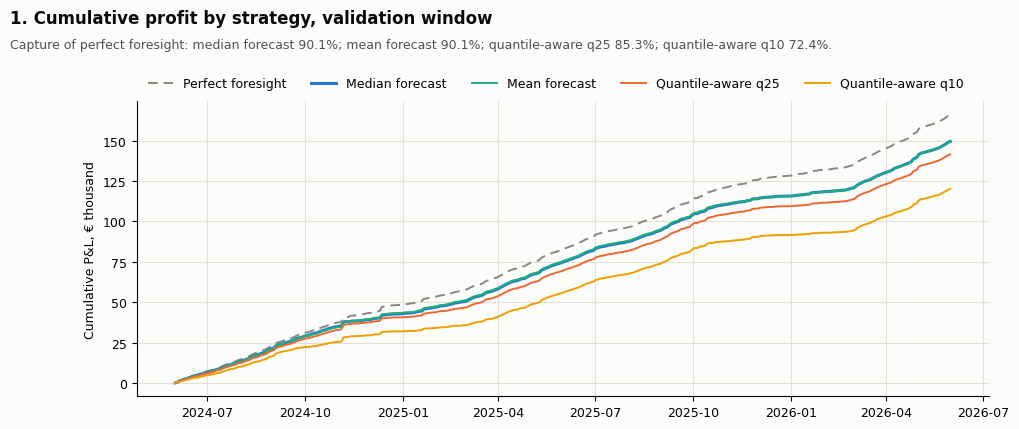

In [3]:
pnl = read("validation", "pnl_daily")
fig, ax = plt.subplots(figsize=(11, 4.4))
for strategy in STRATEGIES:
    daily = pnl[pnl["strategy"] == strategy].sort_values("target_day")
    ax.plot(pd.to_datetime(daily["target_day"]), daily["pnl_eur"].cumsum() / 1000, color=COLORS[strategy],
            linewidth=2.2 if strategy == "median_forecast" else 1.4,
            linestyle=(0, (5, 3)) if strategy == "perfect_foresight" else "-", label=LABELS[strategy])
ax.set_ylabel("Cumulative P&L, € thousand")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=5)
capture = validation["capture_ratio"]
titled(fig, "1. Cumulative profit by strategy, validation window",
       "Capture of perfect foresight: "
       + "; ".join(f"{LABELS[s].lower()} {capture[s]:.1%}" for s in FORECAST_STRATEGIES) + ".", top=0.78)
plt.show()


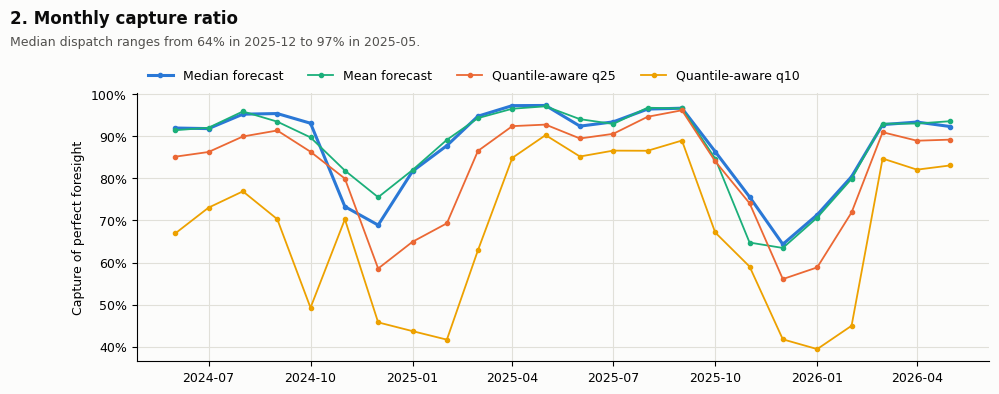

In [4]:
months = read("validation", "monthly_capture")
fig, ax = plt.subplots(figsize=(11, 4))
for strategy in FORECAST_STRATEGIES:
    ax.plot(pd.to_datetime(months["month"]), months[f"{strategy}_capture"], color=COLORS[strategy],
            marker="o", markersize=3, linewidth=2.2 if strategy == "median_forecast" else 1.3,
            label=LABELS[strategy])
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Capture of perfect foresight")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=4)
median = months.set_index("month")["median_forecast_capture"]
titled(fig, "2. Monthly capture ratio",
       f"Median dispatch ranges from {median.min():.0%} in {median.idxmin()} to {median.max():.0%} in "
       f"{median.idxmax()}.", top=0.78)
plt.show()


## Does a better forecast make more money? (T2)

Every model from the Phase 2 comparison, traded with the same battery on the same days. The table gives each model's daily profit minus the production model's, with a 95% interval from a 7-day block bootstrap.

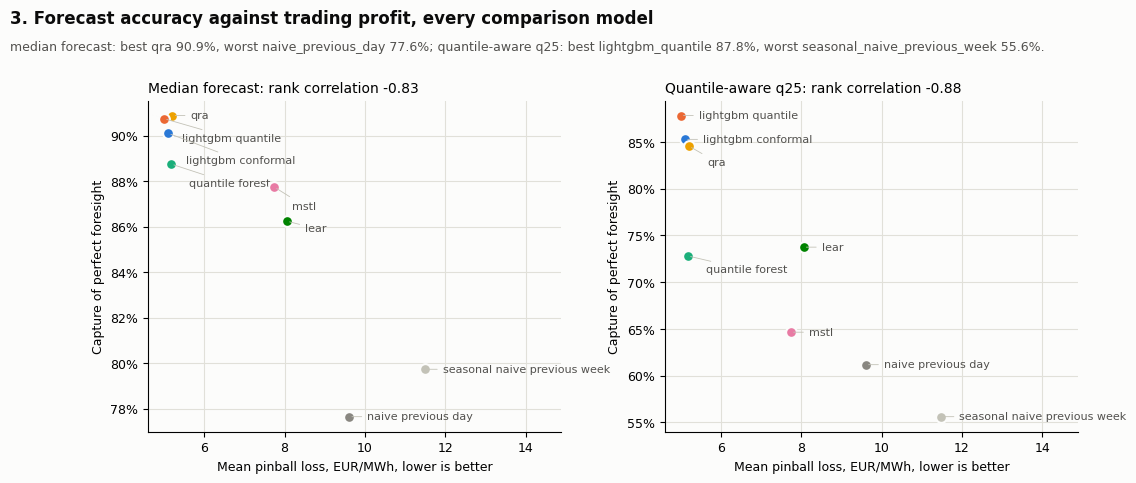

In [5]:
value = summary("decision-value")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fig.subplots_adjust(wspace=0.25)
lines = []
for ax, strategy in zip(axes, ["median_forecast", "quantile_q25"], strict=True):
    part = value[value["strategy"] == strategy].set_index("model")
    span = part["capture_ratio"].max() - part["capture_ratio"].min()
    label_y = None
    for model, row in part.sort_values("capture_ratio", ascending=False).iterrows():
        ax.scatter(row["mean_pinball"], row["capture_ratio"], s=60, color=MODEL_COLORS[model],
                   edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
        label_y = row["capture_ratio"] if label_y is None else min(row["capture_ratio"], label_y - 0.075 * span)
        ax.annotate(model.replace("_", " "), (row["mean_pinball"], row["capture_ratio"]),
                    xytext=(row["mean_pinball"] + 0.45, label_y), textcoords="data", fontsize=8,
                    color=INK2, va="center", arrowprops={"arrowstyle": "-", "color": "#c3c2b7", "linewidth": 0.6})
    ax.set_xlim(part["mean_pinball"].min() - 0.4, part["mean_pinball"].max() + 3.4)
    rho = part["mean_pinball"].corr(part["capture_ratio"], method="spearman")
    best = part["capture_ratio"].idxmax()
    ax.set_title(f"{LABELS[strategy]}: rank correlation {rho:.2f}", loc="left", fontsize=10)
    ax.set_xlabel("Mean pinball loss, EUR/MWh, lower is better")
    ax.set_ylabel("Capture of perfect foresight")
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
    lines.append(f"{LABELS[strategy].lower()}: best {best} {part.loc[best, 'capture_ratio']:.1%}, "
                 f"worst {part['capture_ratio'].idxmin()} {part['capture_ratio'].min():.1%}")
titled(fig, "3. Forecast accuracy against trading profit, every comparison model", "; ".join(lines) + ".",
       top=0.8)
plt.show()


In [6]:
daily = read("decision-value", "pnl_daily")
differences = pd.concat([pnl_differences(daily, base_model=PRODUCTION, strategy=s)
                         for s in ["median_forecast", "mean_forecast", "quantile_q25"]], ignore_index=True)
display(formatted(differences, {"mean_daily_difference_eur": "{:+.2f}", "ci_low_eur": "{:+.2f}",
                                "ci_high_eur": "{:+.2f}", "total_difference_eur": "{:+,.0f}"}))


,model,strategy,days,mean_daily_difference_eur,ci_low_eur,ci_high_eur,total_difference_eur
0,lear,median_forecast,730,-8.78,-11.98,-5.10,"-6,410"
1,lightgbm_quantile,median_forecast,730,+1.46,+0.16,+3.05,"+1,068"
2,mstl,median_forecast,730,-5.36,-7.95,-2.63,"-3,912"
3,naive_previous_day,median_forecast,730,-28.30,-32.28,-24.10,"-20,662"
4,qra,median_forecast,730,+1.77,+0.52,+3.34,"+1,293"
5,quantile_forest,median_forecast,730,-3.07,-5.33,-0.67,"-2,243"
6,seasonal_naive_previous_week,median_forecast,730,-23.57,-27.86,-19.84,"-17,206"
7,lear,mean_forecast,730,-14.68,-19.11,-10.52,"-10,714"
8,lightgbm_quantile,mean_forecast,730,+3.16,+1.70,+4.74,"+2,306"
9,mstl,mean_forecast,730,-5.39,-7.63,-3.32,"-3,937"


## Where an error falls matters more than its size (T2)

Synthetic forecasts built from the realised prices, traded with median dispatch.

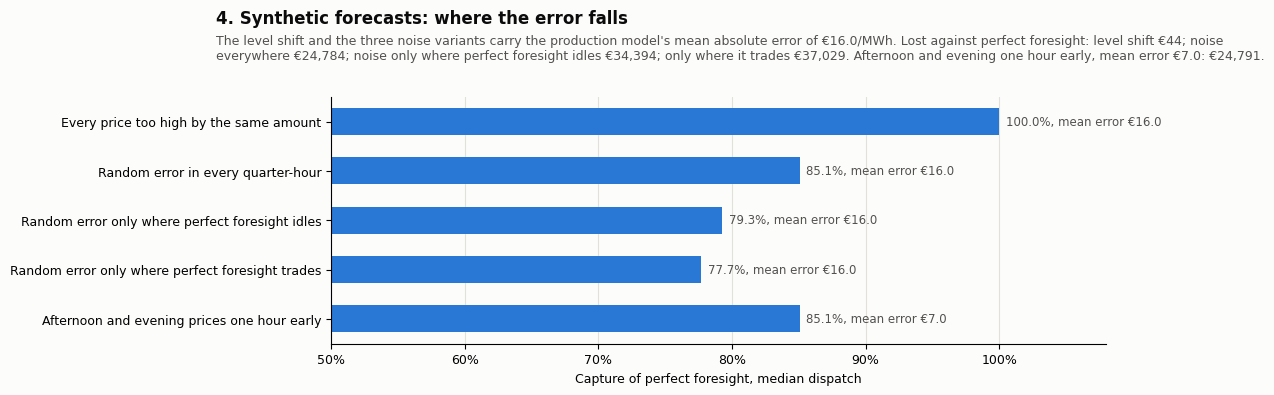

In [7]:
synthetic = summary("synthetic").set_index("variant")
target = notes("synthetic")["target_mae_eur_mwh"]
names = {"level_shift": "Every price too high by the same amount",
         "noise_everywhere": "Random error in every quarter-hour",
         "noise_idle_periods": "Random error only where perfect foresight idles",
         "noise_traded_periods": "Random error only where perfect foresight trades",
         "peak_one_hour_early": "Afternoon and evening prices one hour early"}
order = list(synthetic.index)[::-1]
fig, ax = plt.subplots(figsize=(10, 3.8))
bars = ax.barh([names[v] for v in order], synthetic.loc[order, "capture_ratio"], color="#2a78d6", height=0.55)
for bar, variant in zip(bars, order, strict=True):
    row = synthetic.loc[variant]
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{row['capture_ratio']:.1%}, mean error €{row['mean_mae_eur_mwh']:.1f}", va="center",
            fontsize=8.5, color=INK2)
ax.set_xlim(0.5, 1.08)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Capture of perfect foresight, median dispatch")
ax.grid(axis="y", visible=False)
lost = synthetic["lost_eur"]
early = synthetic.loc["peak_one_hour_early"]
titled(fig, "4. Synthetic forecasts: where the error falls",
       f"The level shift and the three noise variants carry the production model's mean absolute error of "
       f"€{target:.1f}/MWh. Lost against perfect foresight: level shift €{lost['level_shift']:,.0f}; noise "
       f"everywhere €{lost['noise_everywhere']:,.0f}; noise only where perfect foresight idles "
       f"€{lost['noise_idle_periods']:,.0f}; only where it trades €{lost['noise_traded_periods']:,.0f}. "
       f"Afternoon and evening one hour early, mean error €{early['mean_mae_eur_mwh']:.1f}: "
       f"€{early['lost_eur']:,.0f}.", top=0.76)
plt.show()


## Pricing wear (T3)

The optimizer is given a range of wear prices; profit is always charged the battery's true wear.

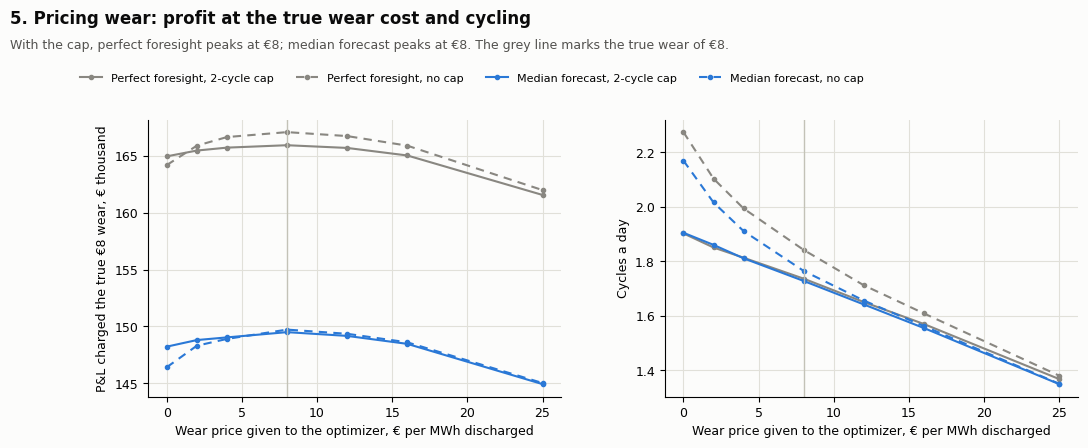

In [8]:
sweep = summary("degradation")
true_wear = sweep["true_wear_eur_per_mwh"].iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
fig.subplots_adjust(wspace=0.25)
best = []
for strategy in ["perfect_foresight", "median_forecast"]:
    for capped in (True, False):
        part = sweep[(sweep["strategy"] == strategy) & (sweep["cycle_cap"].notna() == capped)]
        part = part.sort_values("optimizer_wear_eur_per_mwh")
        style = "-" if capped else (0, (4, 3))
        label = f"{LABELS[strategy]}, {'2-cycle cap' if capped else 'no cap'}"
        axes[0].plot(part["optimizer_wear_eur_per_mwh"], part["pnl_true_wear_eur"] / 1000, color=COLORS[strategy],
                     linestyle=style, marker="o", markersize=3, label=label)
        axes[1].plot(part["optimizer_wear_eur_per_mwh"], part["cycles_per_day"], color=COLORS[strategy],
                     linestyle=style, marker="o", markersize=3, label=label)
        if capped:
            top = part.loc[part["pnl_true_wear_eur"].idxmax()]
            best.append(f"{LABELS[strategy].lower()} peaks at €{top['optimizer_wear_eur_per_mwh']:g}")
for ax in axes:
    ax.axvline(true_wear, color="#c3c2b7", linewidth=1)
    ax.set_xlabel("Wear price given to the optimizer, € per MWh discharged")
axes[0].set_ylabel(f"P&L charged the true €{true_wear:g} wear, € thousand")
axes[1].set_ylabel("Cycles a day")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower left", bbox_to_anchor=(0.06, 0.80), ncols=4, fontsize=8)
titled(fig, "5. Pricing wear: profit at the true wear cost and cycling",
       f"With the cap, {'; '.join(best)}. The grey line marks the true wear of €{true_wear:g}.", top=0.74)
plt.show()


## What forecast errors cost, by hour and direction (T1)

Each day's gap to perfect foresight is split into Shapley shares: the average profit gained by correcting one group of errors, over many orders of correcting them. The shares add up to the gap; a negative share means that, averaged over those orders, correcting that group lowers profit while other errors remain. The direction comes from the median forecast's error for every strategy; before October 2025 an hourly product takes the direction of its mean error.

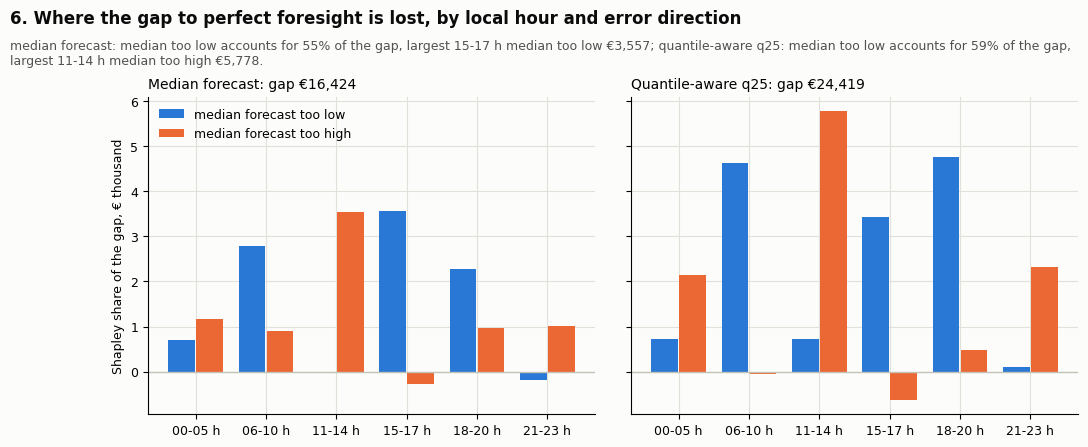

In [9]:
shares = summary("attribution").set_index("strategy")
blocks = [name for name, _ in HOUR_BLOCKS]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
fig.subplots_adjust(wspace=0.08)
lines = []
x = np.arange(len(blocks))
for ax, strategy in zip(axes, shares.index, strict=True):
    row = shares.loc[strategy]
    for offset, direction in ((-0.2, "under"), (0.2, "over")):
        values = [row[f"cost_{block}_{direction}_eur"] / 1000 for block in blocks]
        ax.bar(x + offset, values, width=0.38, color=DIRECTION_COLORS[direction],
               label=f"median forecast too {'low' if direction == 'under' else 'high'}")
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.set_xticks(x, [f"{b} h" for b in blocks])
    ax.set_title(f"{LABELS[strategy]}: gap €{row['gap_eur']:,.0f}", loc="left", fontsize=10)
    groups = {f"{b} {d}": row[f"cost_{b}_{d}_eur"] for b in blocks for d in ("under", "over")}
    worst = max(groups, key=groups.get)
    lines.append(f"{LABELS[strategy].lower()}: median too low accounts for {row['cost_under_eur'] / row['gap_eur']:.0%} "
                 f"of the gap, largest {worst.replace(' under', ' h median too low').replace(' over', ' h median too high')} "
                 f"€{groups[worst]:,.0f}")
axes[0].set_ylabel("Shapley share of the gap, € thousand")
axes[0].legend(loc="upper left")
titled(fig, "6. Where the gap to perfect foresight is lost, by local hour and error direction",
       "; ".join(lines) + ".", top=0.8)
plt.show()


In [10]:
costs = read("attribution", "costs")
grouped = costs.groupby(["strategy", "block", "direction"])
table = pd.DataFrame({"share_eur": grouped["cost_eur"].sum(),
                      "periods": grouped["periods"].sum(),
                      "mean_abs_error_eur_mwh": (costs.assign(w=costs["mean_abs_error_eur_mwh"] * costs["periods"])
                                                 .groupby(["strategy", "block", "direction"])["w"].sum()
                                                 / grouped["periods"].sum())}).reset_index()
table["share_per_period_eur"] = table["share_eur"] / table["periods"]
display(formatted(table, {"share_eur": "{:+,.0f}", "periods": "{:,.0f}", "mean_abs_error_eur_mwh": "{:.1f}",
                          "share_per_period_eur": "{:+.3f}"}))


,strategy,block,direction,share_eur,periods,mean_abs_error_eur_mwh,share_per_period_eur
0,median_forecast,00-05,over,"+1,177","8,981",9.4,+0.131
1,median_forecast,00-05,under,+693,"8,539",8.3,+0.081
2,median_forecast,06-10,over,+892,"7,329",16.4,+0.122
3,median_forecast,06-10,under,"+2,782","7,271",17.1,+0.383
4,median_forecast,11-14,over,"+3,540","5,705",21.6,+0.620
5,median_forecast,11-14,under,-30,"5,975",18.9,-0.005
6,median_forecast,15-17,over,-271,"4,364",21.0,-0.062
7,median_forecast,15-17,under,"+3,557","4,396",22.4,+0.809
8,median_forecast,18-20,over,+963,"4,378",18.5,+0.220
9,median_forecast,18-20,under,"+2,280","4,382",25.7,+0.520


## Hold-out (T6)

The setup recorded in the decision log on 14 September 2026, run once on days no earlier phase had seen: the same battery and strategies, the production model and the three models it is compared with, forecast walk-forward with the validation refit schedules.

In [11]:
holdout = summary("holdout")
value = summary("decision-value")
hold_months = set(pd.to_datetime(read("holdout", "pnl_daily")["target_day"]).dt.month)
same_months = capture_in_months(read("decision-value", "pnl_daily"), hold_months).set_index(["model", "strategy"])
rows = []
for model in dict.fromkeys(holdout["model"]):
    for strategy in STRATEGIES:
        h = holdout[(holdout["model"] == model) & (holdout["strategy"] == strategy)].iloc[0]
        v = value[(value["model"] == model) & (value["strategy"] == strategy)].iloc[0]
        rows.append({"model": model, "strategy": LABELS[strategy],
                     "validation capture": v["capture_ratio"],
                     "validation capture, same months": same_months.loc[(model, strategy), "capture_ratio"],
                     "hold-out capture": h["capture_ratio"],
                     "validation € a day": v["pnl_eur"] / v["days"], "hold-out € a day": h["pnl_eur"] / h["days"],
                     "hold-out losing days": h["losing_days"], "hold-out max drawdown, €": h["max_drawdown_eur"]})
comparison = pd.DataFrame(rows)
display(formatted(comparison, {"validation capture": "{:.1%}", "validation capture, same months": "{:.1%}",
                               "hold-out capture": "{:.1%}",
                               "validation € a day": "{:,.1f}", "hold-out € a day": "{:,.1f}",
                               "hold-out losing days": "{:.0f}", "hold-out max drawdown, €": "{:,.1f}"}))


,model,strategy,validation capture,"validation capture, same months",hold-out capture,validation € a day,hold-out € a day,hold-out losing days,"hold-out max drawdown, €"
0,lightgbm_conformal,Perfect foresight,100.0%,100.0%,100.0%,227.3,336.6,0,0.0
1,lightgbm_conformal,Median forecast,90.1%,94.3%,91.0%,204.8,306.2,0,0.0
2,lightgbm_conformal,Mean forecast,90.1%,94.3%,90.7%,204.8,305.3,0,0.0
3,lightgbm_conformal,Quantile-aware q25,85.3%,90.7%,88.8%,193.8,298.9,0,0.0
4,lightgbm_conformal,Quantile-aware q10,72.4%,79.5%,86.0%,164.6,289.6,0,0.0
5,lightgbm_quantile,Perfect foresight,100.0%,100.0%,100.0%,227.3,336.6,0,0.0
6,lightgbm_quantile,Median forecast,90.7%,94.3%,92.3%,206.3,310.6,0,0.0
7,lightgbm_quantile,Mean forecast,91.5%,94.6%,93.2%,208.0,313.9,0,0.0
8,lightgbm_quantile,Quantile-aware q25,87.8%,91.7%,85.4%,199.6,287.6,0,0.0
9,lightgbm_quantile,Quantile-aware q10,78.1%,84.0%,80.5%,177.6,271.2,0,0.0


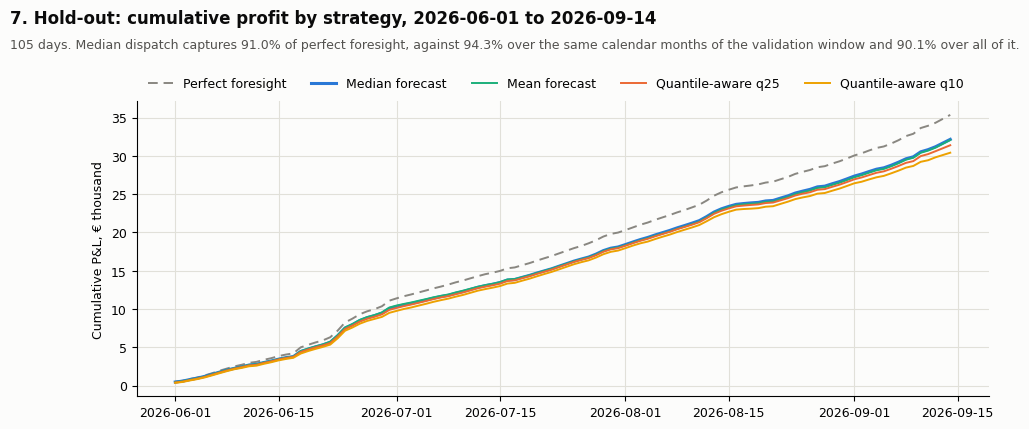

In [12]:
hold_pnl = read("holdout", "pnl_daily")
mine = hold_pnl[hold_pnl["model"] == PRODUCTION]
fig, ax = plt.subplots(figsize=(11, 4.4))
for strategy in STRATEGIES:
    daily = mine[mine["strategy"] == strategy].sort_values("target_day")
    ax.plot(pd.to_datetime(daily["target_day"]), daily["pnl_eur"].cumsum() / 1000, color=COLORS[strategy],
            linewidth=2.2 if strategy == "median_forecast" else 1.4,
            linestyle=(0, (5, 3)) if strategy == "perfect_foresight" else "-", label=LABELS[strategy])
ax.set_ylabel("Cumulative P&L, € thousand")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncols=5)
mine_summary = holdout[holdout["model"] == PRODUCTION].set_index("strategy")
days = sorted(mine["target_day"].unique())
titled(fig, f"7. Hold-out: cumulative profit by strategy, {days[0]} to {days[-1]}",
       f"{len(days)} days. Median dispatch captures {mine_summary.loc['median_forecast', 'capture_ratio']:.1%} "
       f"of perfect foresight, against {same_months.loc[(PRODUCTION, 'median_forecast'), 'capture_ratio']:.1%} over "
       f"the same calendar months of the validation window and {validation.loc['median_forecast', 'capture_ratio']:.1%} "
       f"over all of it.",
       top=0.78)
plt.show()


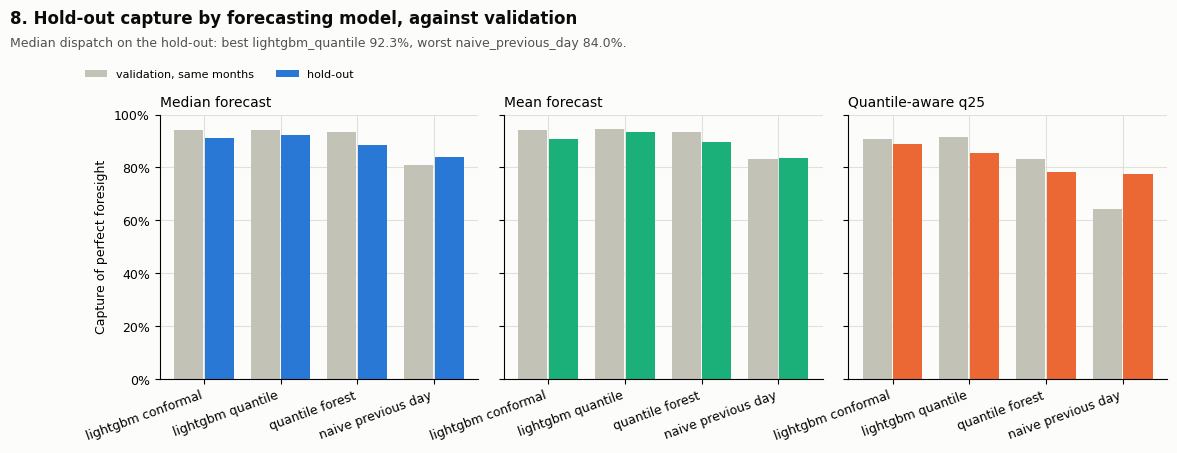

In [13]:
strategies_shown = ["median_forecast", "mean_forecast", "quantile_q25"]
models_shown = list(dict.fromkeys(holdout["model"]))
fig, axes = plt.subplots(1, len(strategies_shown), figsize=(13, 4.2), sharey=True)
fig.subplots_adjust(wspace=0.08)
x = np.arange(len(models_shown))
for ax, strategy in zip(axes, strategies_shown, strict=True):
    part = comparison[comparison["strategy"] == LABELS[strategy]].set_index("model").loc[models_shown]
    ax.bar(x - 0.2, part["validation capture, same months"], width=0.38, color="#c3c2b7",
           label="validation, same months")
    ax.bar(x + 0.2, part["hold-out capture"], width=0.38, color=COLORS[strategy], label="hold-out")
    ax.set_xticks(x, [m.replace("_", " ") for m in models_shown], rotation=20, ha="right")
    ax.set_title(LABELS[strategy], loc="left", fontsize=10)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
    ax.set_ylim(0, 1)
axes[0].set_ylabel("Capture of perfect foresight")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["validation, same months", "hold-out"], loc="lower left", bbox_to_anchor=(0.06, 0.80), ncols=2,
           fontsize=8)
best = comparison[comparison["strategy"] == LABELS["median_forecast"]].set_index("model")["hold-out capture"]
titled(fig, "8. Hold-out capture by forecasting model, against validation",
       f"Median dispatch on the hold-out: best {best.idxmax()} {best.max():.1%}, worst {best.idxmin()} {best.min():.1%}.",
       top=0.74)
plt.show()


Forecast accuracy on the hold-out days, against the validation window:

In [14]:
from src.forecasting.evaluate import score

accuracy = {}
for model in models_shown:
    frame = pd.read_parquet(settings.data.processed_path / "forecasts" / "holdout" / f"{model}.parquet")
    frame = frame[frame["target_day"].isin(days)]
    s = score(frame, settings.forecasting.quantiles)
    v = value[(value["model"] == model) & (value["strategy"] == "median_forecast")].iloc[0]
    accuracy[model] = {"validation pinball": v["mean_pinball"], "hold-out pinball": s["mean pinball"],
                       "hold-out MAE of median": s["MAE of median"], "validation coverage 90%": v["coverage_90"],
                       "hold-out coverage 90%": s["coverage 90%"]}
display(formatted(pd.DataFrame(accuracy).T.reset_index(names="model"),
                  {"validation pinball": "{:.2f}", "hold-out pinball": "{:.2f}", "hold-out MAE of median": "{:.2f}",
                   "validation coverage 90%": "{:.1%}", "hold-out coverage 90%": "{:.1%}"}))


,model,validation pinball,hold-out pinball,hold-out MAE of median,validation coverage 90%,hold-out coverage 90%
0,lightgbm_conformal,5.11,6.95,20.24,85.6%,77.8%
1,lightgbm_quantile,5.00,6.57,20.27,73.3%,73.0%
2,quantile_forest,5.18,6.69,21.87,94.6%,93.6%
3,naive_previous_day,9.61,10.74,32.39,86.4%,85.4%


Daily profit of each model minus the production model's on the hold-out, with 95% block-bootstrap intervals. This is evidence, not a selection: the production model was frozen before the hold-out.

In [15]:
hold_differences = pd.concat([pnl_differences(hold_pnl, base_model=PRODUCTION, strategy=s)
                              for s in ["median_forecast", "mean_forecast"]], ignore_index=True)
display(formatted(hold_differences, {"mean_daily_difference_eur": "{:+.2f}", "ci_low_eur": "{:+.2f}",
                                     "ci_high_eur": "{:+.2f}", "total_difference_eur": "{:+,.0f}"}))


,model,strategy,days,mean_daily_difference_eur,ci_low_eur,ci_high_eur,total_difference_eur
0,lightgbm_quantile,median_forecast,105,+4.37,+2.03,+6.73,+459
1,naive_previous_day,median_forecast,105,-23.35,-31.33,-12.54,"-2,451"
2,quantile_forest,median_forecast,105,-8.20,-9.37,-0.56,-861
3,lightgbm_quantile,mean_forecast,105,+8.57,+5.69,+11.48,+900
4,naive_previous_day,mean_forecast,105,-24.58,-33.51,-12.41,"-2,581"
5,quantile_forest,mean_forecast,105,-3.34,-4.87,+3.08,-350


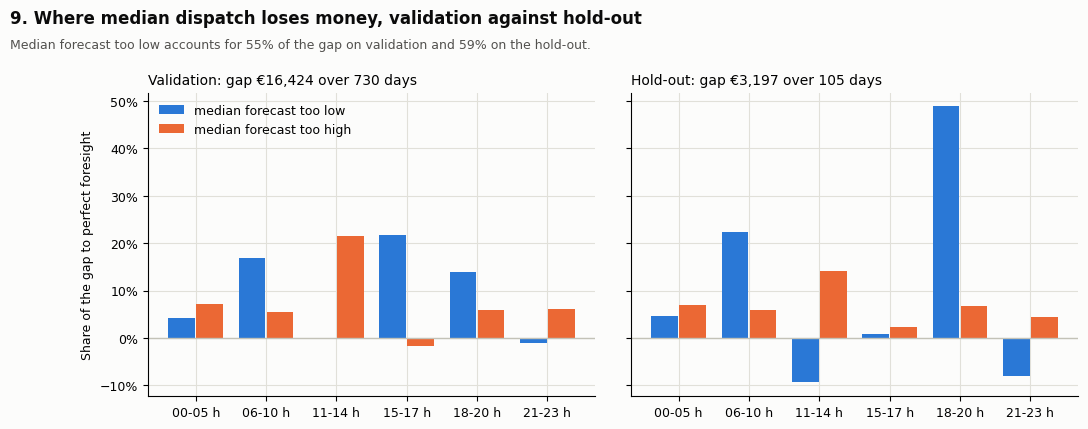

In [16]:
hold_shares = read("holdout", "attribution_summary").set_index("strategy").loc["median_forecast"]
val_shares = shares.loc["median_forecast"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
fig.subplots_adjust(wspace=0.08)
x = np.arange(len(blocks))
for ax, (name, row) in zip(axes, [("Validation", val_shares), ("Hold-out", hold_shares)], strict=True):
    for offset, direction in ((-0.2, "under"), (0.2, "over")):
        values = [row[f"cost_{block}_{direction}_eur"] / row["gap_eur"] for block in blocks]
        ax.bar(x + offset, values, width=0.38, color=DIRECTION_COLORS[direction],
               label=f"median forecast too {'low' if direction == 'under' else 'high'}")
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.set_xticks(x, [f"{b} h" for b in blocks])
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
    ax.set_title(f"{name}: gap €{row['gap_eur']:,.0f} over {int(row['days'])} days", loc="left", fontsize=10)
axes[0].set_ylabel("Share of the gap to perfect foresight")
axes[0].legend(loc="upper left")
titled(fig, "9. Where median dispatch loses money, validation against hold-out",
       f"Median forecast too low accounts for {val_shares['cost_under_eur'] / val_shares['gap_eur']:.0%} of the gap on "
       f"validation and {hold_shares['cost_under_eur'] / hold_shares['gap_eur']:.0%} on the hold-out.", top=0.8)
plt.show()
